## 1. 공통 설정 및 데이터 불러오기

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torch.optim.optimizer import Optimizer
from PIL import Image
import os
import time
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from skimage.io import imread

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [2]:
data_dir = './data'
train_path = './data/Train'
test_path = './data'

In [3]:
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)', 
            2:'Speed limit (50km/h)', 
            3:'Speed limit (60km/h)', 
            4:'Speed limit (70km/h)', 
            5:'Speed limit (80km/h)', 
            6:'End of speed limit (80km/h)', 
            7:'Speed limit (100km/h)', 
            8:'Speed limit (120km/h)', 
            9:'No passing', 
            10:'No passing veh over 3.5 tons', 
            11:'Right-of-way at intersection', 
            12:'Priority road', 
            13:'Yield', 
            14:'Stop', 
            15:'No vehicles', 
            16:'Veh > 3.5 tons prohibited', 
            17:'No entry', 
            18:'General caution', 
            19:'Dangerous curve left', 
            20:'Dangerous curve right', 
            21:'Double curve', 
            22:'Bumpy road', 
            23:'Slippery road', 
            24:'Road narrows on the right', 
            25:'Road work', 
            26:'Traffic signals', 
            27:'Pedestrians', 
            28:'Children crossing', 
            29:'Bicycles crossing', 
            30:'Beware of ice/snow',
            31:'Wild animals crossing', 
            32:'End speed + passing limits', 
            33:'Turn right ahead', 
            34:'Turn left ahead', 
            35:'Ahead only', 
            36:'Go straight or right', 
            37:'Go straight or left', 
            38:'Keep right', 
            39:'Keep left', 
            40:'Roundabout mandatory', 
            41:'End of no passing', 
            42:'End no passing veh > 3.5 tons' }

--- 클래스 분포 확인 ---


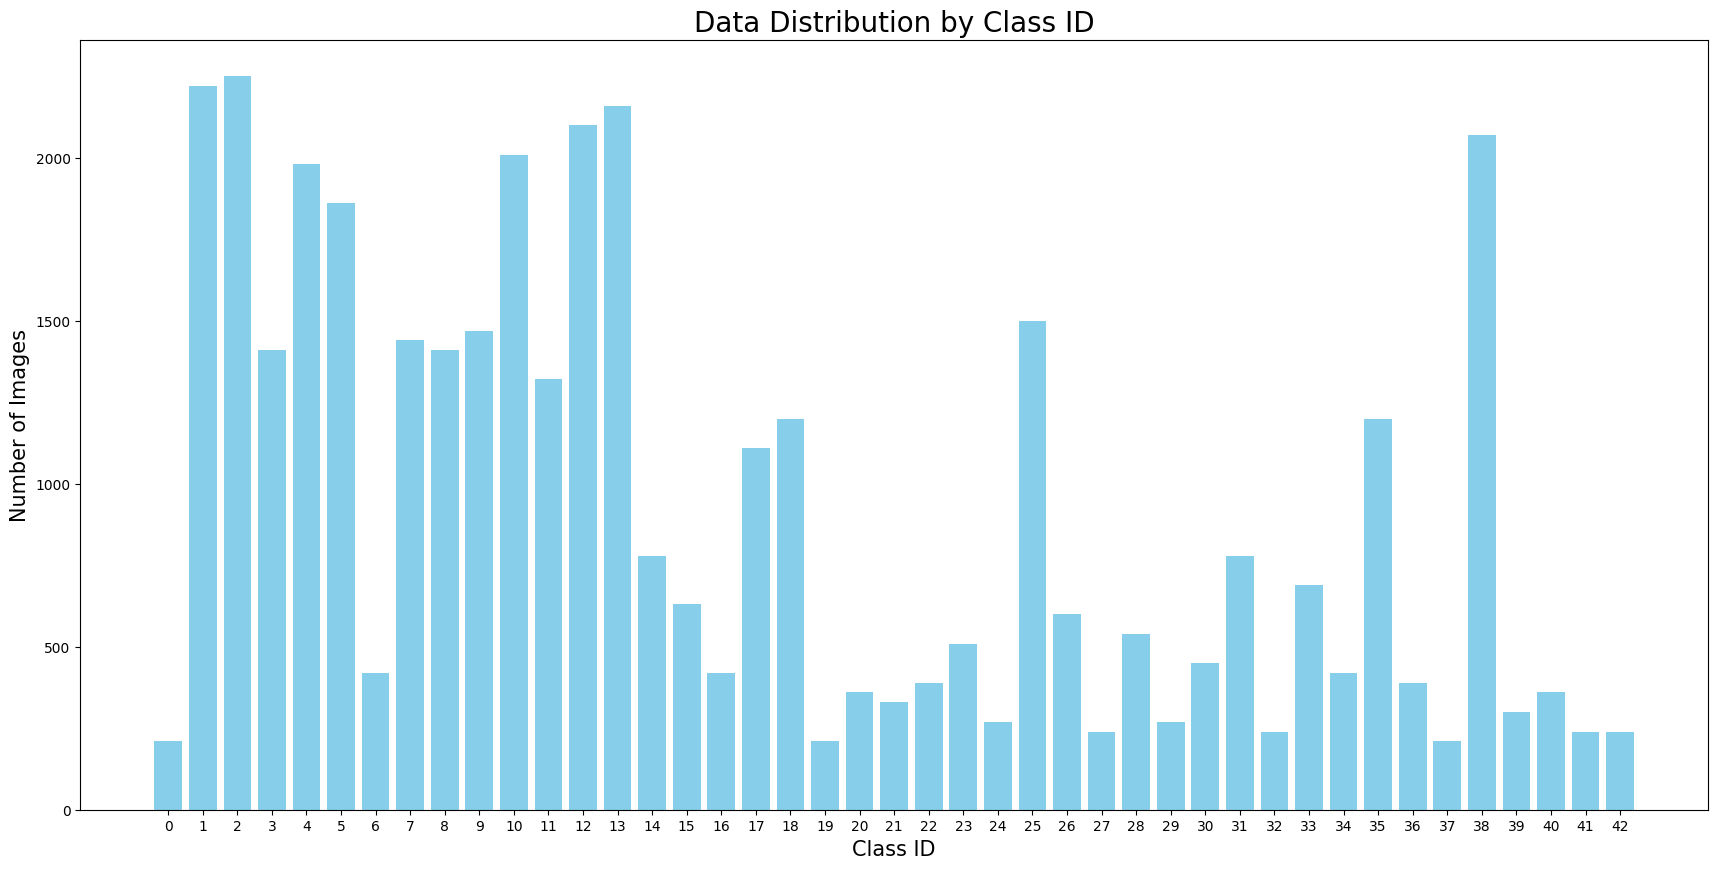

In [4]:
print("--- 클래스 분포 확인 ---")
folders = sorted(os.listdir(train_path), key=lambda x: int(x))

train_number = []
class_num = []

for folder in folders:
    train_files = os.listdir(os.path.join(train_path, folder))
    train_number.append(len(train_files))
    class_num.append(int(folder)) 

plt.figure(figsize=(21,10))  
plt.bar(class_num, train_number, color='skyblue')
plt.xticks(class_num)
plt.xlabel('Class ID', fontsize=15)
plt.ylabel('Number of Images', fontsize=15)
plt.title('Data Distribution by Class ID', fontsize=20)
plt.show()

--- 테스트 이미지 샘플 확인 ---


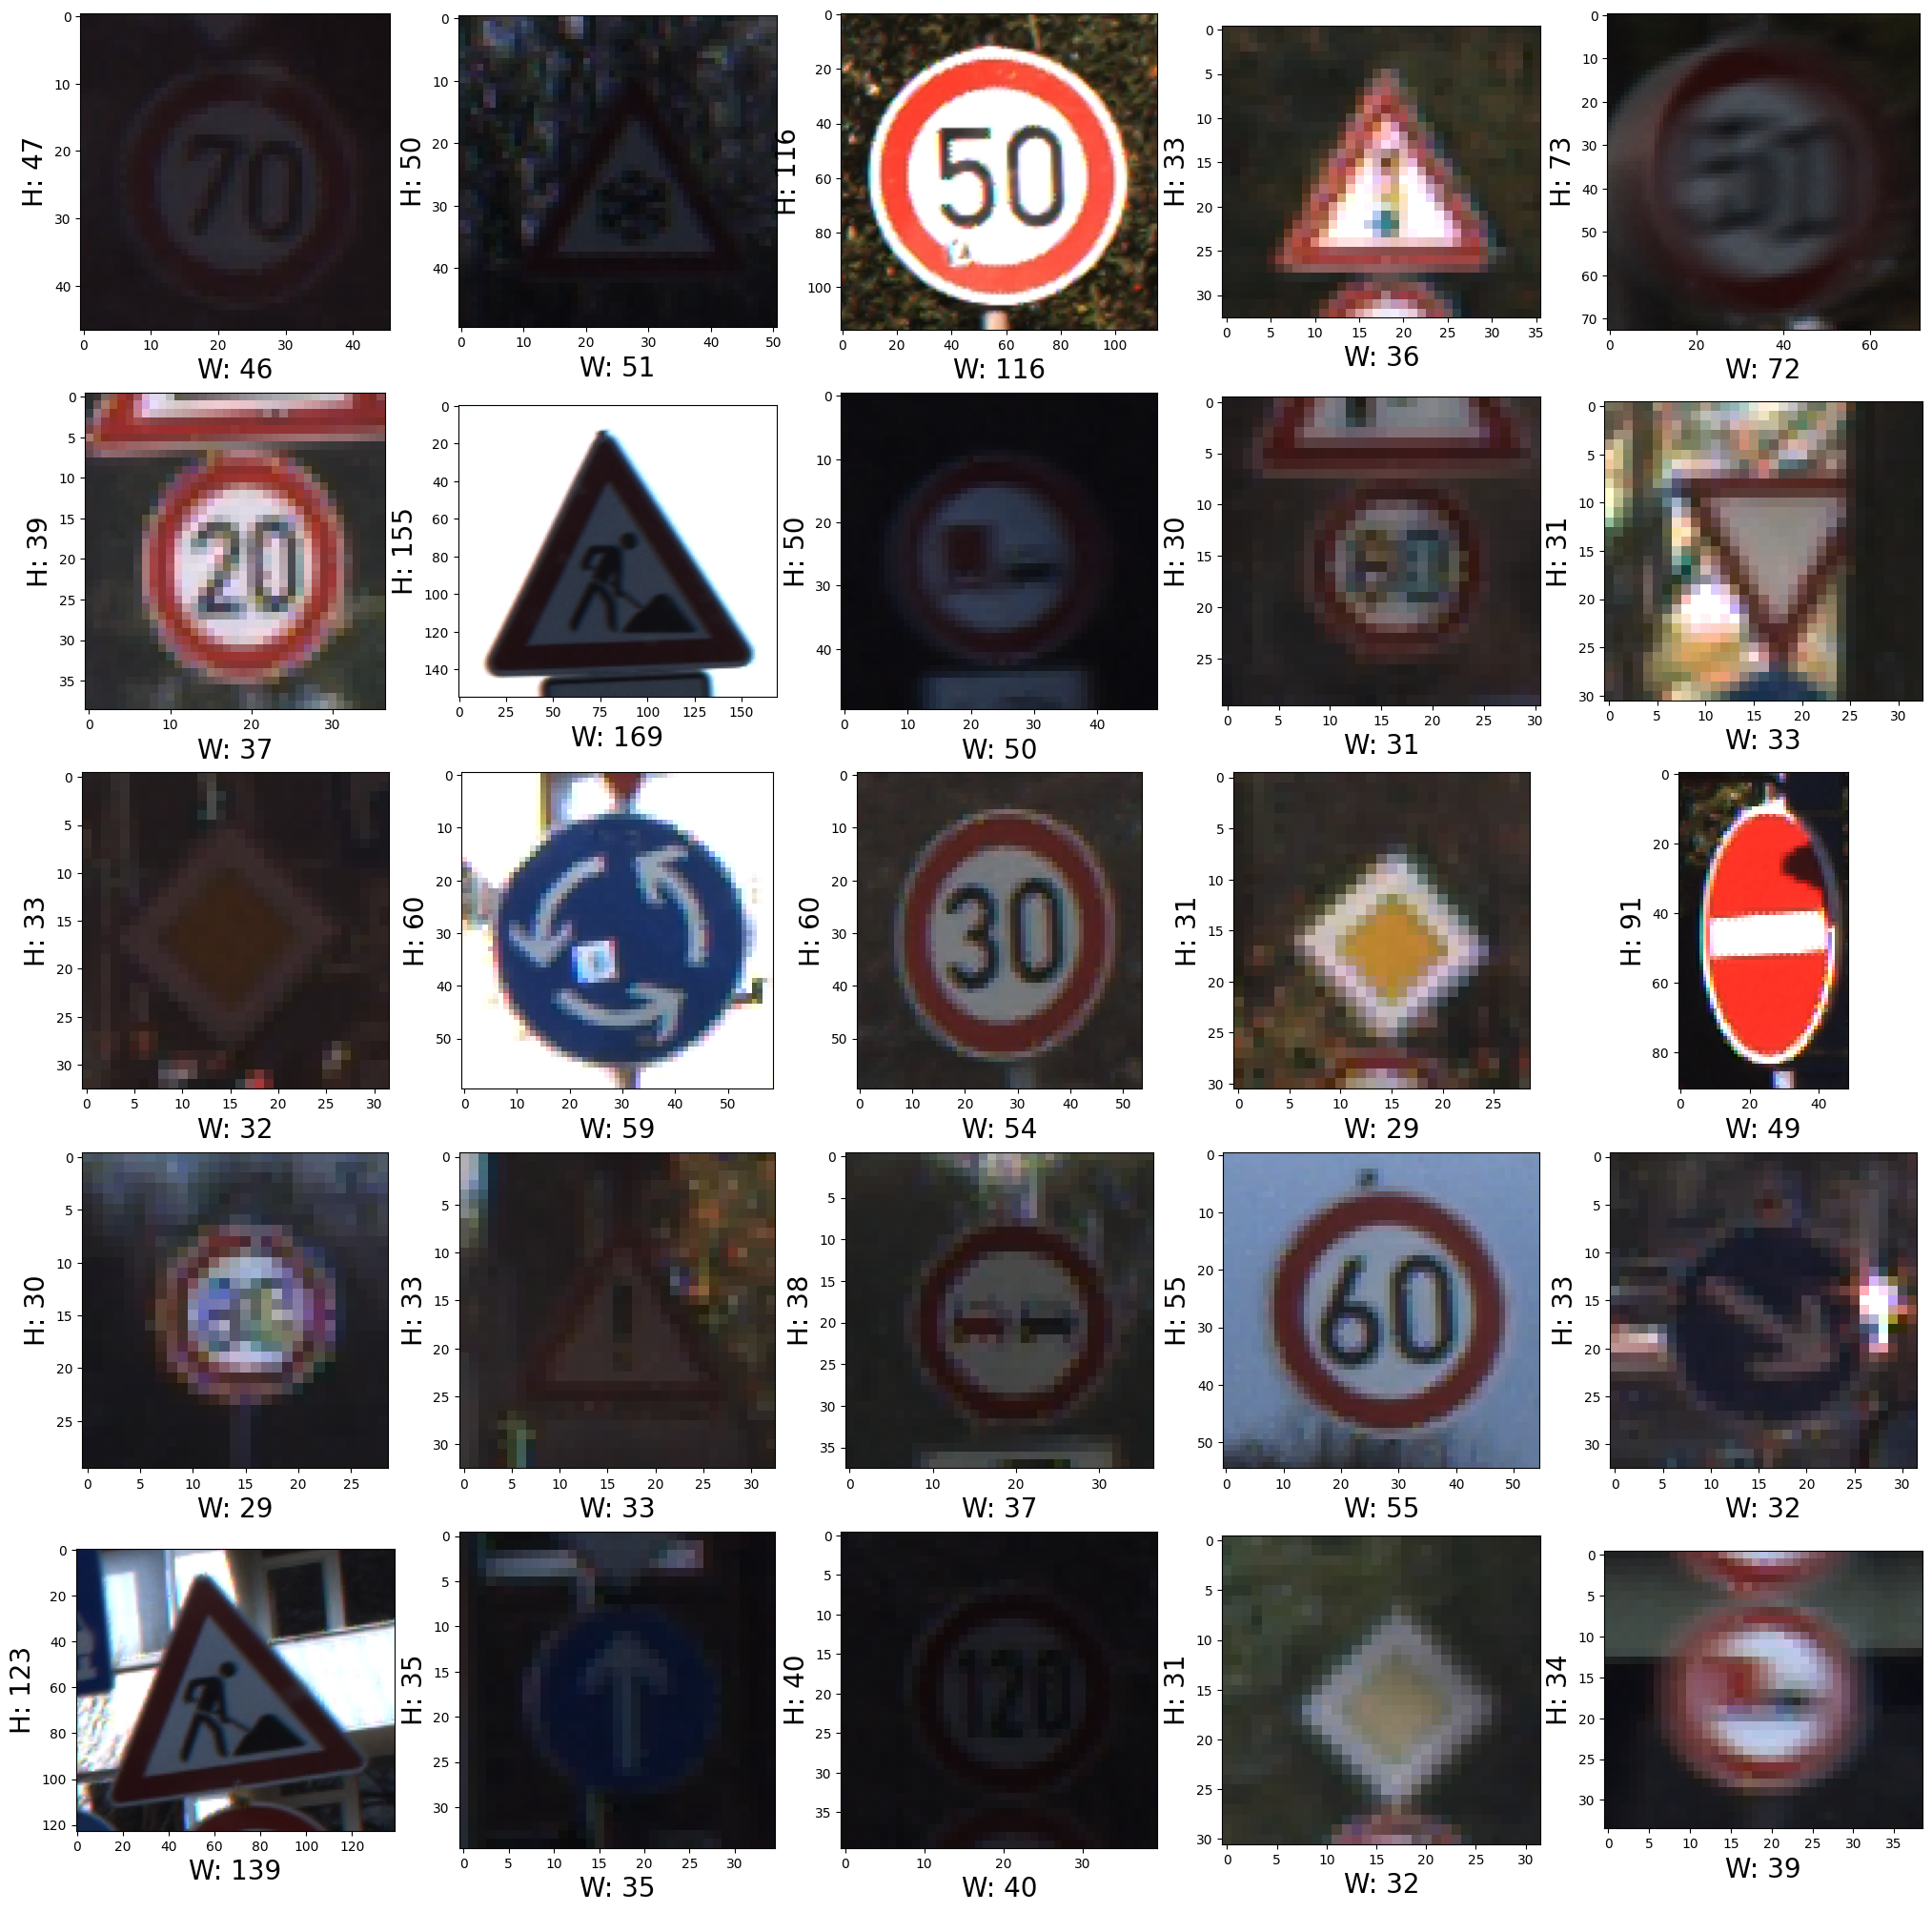

In [5]:
print("--- 테스트 이미지 샘플 확인 ---")
test = pd.read_csv(os.path.join(data_dir, 'Test.csv'))
imgs = test["Path"].values

plt.figure(figsize=(25,25))
for i in range(1, 26):
    plt.subplot(5, 5, i)
    random_img_path = os.path.join(data_dir, random.choice(imgs))
    rand_img = imread(random_img_path)
    plt.imshow(rand_img)
    plt.grid(False) 
    plt.xlabel(f"W: {rand_img.shape[1]}", fontsize=20)
    plt.ylabel(f"H: {rand_img.shape[0]}", fontsize=20)
plt.show()

In [6]:
print("\n--- Train 전체 이미지 평균 크기 확인 ---")
train = pd.read_csv(os.path.join(data_dir, 'Train.csv'))

if 'Width' in train.columns and 'Height' in train.columns:
    avg_width = train['Width'].mean()
    avg_height = train['Height'].mean()
    
    print(f"총 Train 이미지 개수 : {len(train)}장")
    print(f"평균 가로 크기 (Width): {avg_width:.2f} 픽셀")
    print(f"평균 세로 크기 (Height): {avg_height:.2f} 픽셀")


--- Train 전체 이미지 평균 크기 확인 ---
총 Train 이미지 개수 : 39209장
평균 가로 크기 (Width): 50.84 픽셀
평균 세로 크기 (Height): 50.33 픽셀


In [7]:
class GTSRBDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_train=True):
        self.root_dir = root_dir
        self.transform = transform
        self.is_train = is_train
        if self.is_train:
            self.samples = []
            for class_id in sorted(os.listdir(root_dir)):
                class_path = os.path.join(root_dir, class_id)
                if os.path.isdir(class_path):
                    for img_name in sorted(os.listdir(class_path)):
                        if img_name.endswith('.png'):
                            self.samples.append((os.path.join(class_path, img_name), int(class_id)))
        else:
            self.csv_data = pd.read_csv(os.path.join(root_dir, 'Test.csv'))
            
    def __len__(self):
        return len(self.samples) if self.is_train else len(self.csv_data)
        
    def __getitem__(self, idx):
        if self.is_train:
            img_path, label = self.samples[idx]
        else:
            row = self.csv_data.iloc[idx]
            img_path = os.path.join(self.root_dir, row['Path'])
            label = int(row['ClassId'])
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

class SAM(Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        params = list(params)
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(params, **kwargs)

    @torch.no_grad()
    def first_step(self):
        grad_norm = self._grad_norm()
        scale = self.defaults["rho"] / (grad_norm + 1e-12)
        for p in self.param_groups[0]["params"]:
            if p.grad is None: continue
            e_w = p.grad * scale.to(p.device)
            p.add_(e_w)
            self.state[p]["e_w"] = e_w

    @torch.no_grad()
    def second_step(self):
        for p in self.param_groups[0]["params"]:
            if p.grad is None: continue
            p.sub_(self.state[p]["e_w"])
        self.base_optimizer.step()

    def zero_grad(self):
        self.base_optimizer.zero_grad()

    def _grad_norm(self):
        device = self.param_groups[0]["params"][0].device
        norm = torch.norm(
            torch.stack([
                p.grad.norm(2).to(device)
                for p in self.param_groups[0]["params"]
                if p.grad is not None
            ])
        )
        return norm

## 2. 모델 아키텍처 정의

In [8]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, dilation=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size, \
                                   padding=padding, dilation=dilation, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            DepthwiseSeparableConv(channels, channels),
            DepthwiseSeparableConv(channels, channels)
        )
    def forward(self, x):
        return x + self.conv(x)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden_dim = max(channels // reduction, 4)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, channels),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        b, c, _, _ = x.size()
        weight = self.se(x).view(b, c, 1, 1)
        return x * weight

class DSSEBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            DepthwiseSeparableConv(channels, channels),
            DepthwiseSeparableConv(channels, channels),
            SEBlock(channels)
        )
    def forward(self, x):
        return x + self.conv(x)

# --- Architectures ---
class NaiveCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(2304, 512),
            nn.ReLU(),
            nn.Linear(512, 43)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

class GAPOnlyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Global Average Pooling: (Batch, 256, H, W) -> (Batch, 256, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, 43)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class DSConvCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(3, 32, kernel_size=5)
        self.conv2 = DepthwiseSeparableConv(32, 64, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2)
        self.conv3 = DepthwiseSeparableConv(64, 128, kernel_size=3)
        self.conv4 = DepthwiseSeparableConv(128, 256, kernel_size=3)
        self.pool2 = nn.MaxPool2d(2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, 43)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool2(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class DSResidualNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(3, 32, kernel_size=5)
        self.conv2 = DepthwiseSeparableConv(32, 64, kernel_size=5)
        self.res1 = ResidualBlock(64)
        self.pool1 = nn.MaxPool2d(2)
        self.conv3 = DepthwiseSeparableConv(64, 128, kernel_size=3)
        self.conv4 = DepthwiseSeparableConv(128, 256, kernel_size=3)
        self.res2 = ResidualBlock(256)
        self.pool2 = nn.MaxPool2d(2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, 43)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.res1(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.res2(x)
        x = self.pool2(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class DSResidualSENet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            DepthwiseSeparableConv(3, 32, kernel_size=3),
            nn.MaxPool2d(2),
            DepthwiseSeparableConv(32, 64, kernel_size=3),
            nn.MaxPool2d(2),
            DSSEBlock(64),
            DepthwiseSeparableConv(64, 128, kernel_size=3),
            nn.MaxPool2d(2),
            DSSEBlock(128),
            DepthwiseSeparableConv(128, 256, kernel_size=3),
            nn.MaxPool2d(2),
            DSSEBlock(256)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 43)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class DSResidualNetDilation(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = DepthwiseSeparableConv(3, 32, kernel_size=5, padding=4, dilation=2)
        self.conv2 = DepthwiseSeparableConv(32, 64, kernel_size=5, padding=4, dilation=2)
        self.res1 = ResidualBlock(64)
        self.pool1 = nn.MaxPool2d(2)
        self.conv3 = DepthwiseSeparableConv(64,128,kernel_size=3)
        self.conv4 = DepthwiseSeparableConv(128,256,kernel_size=3)
        self.res2 = ResidualBlock(256)
        self.pool2 = nn.MaxPool2d(2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, 43)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.res1(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.res2(x)
        x = self.pool2(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


## 3. 학습 및 유틸리티 함수

In [9]:
def print_parameters(model, model_name, verbose=True):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if verbose:
        print(f"\n{'='*20} [{model_name} Layer Details] {'='*20}")
        print(f"{'Layer Name':<40} | {'Shape':<25} | {'Parameters':<15}")
        print("-" * 85)
        for name, param in model.named_parameters():
            if param.requires_grad:
                num = param.numel()
                shape_str = str(list(param.shape))
                print(f"{name:<40} | {shape_str:<25} | {num:>15,}")
        print("-" * 85)
        print(f"{'TOTAL TRAINABLE PARAMETERS':<68} | {total_params:>15,}")
        print('='*85)
    return total_params

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, model_name, use_sam=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            if use_sam:
                outputs = model(images)
                loss = criterion(outputs, labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.first_step()
                optimizer.zero_grad()
                criterion(model(images), labels).backward()
                optimizer.second_step()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        curr_val_acc = val_correct / val_total
        history['loss'].append(train_loss/len(train_loader))
        history['accuracy'].append(train_correct/train_total)
        history['val_loss'].append(val_loss/len(test_loader))
        history['val_accuracy'].append(curr_val_acc)
        print(f"Epoch {epoch+1} | Loss: {history['loss'][-1]:.4f} | Acc: {history['accuracy'][-1]*100:.2f}% | Val Acc: {curr_val_acc*100:.2f}%")
        if curr_val_acc > best_val_acc:
            best_val_acc = curr_val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
    return history

def evaluate_model(model, test_loader, model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    correct = 0
    total = 0
    print(f"--- Evaluating {model_name} ---")
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    final_acc = 100 * correct / total
    print(f"Total Images: {total}")
    print(f"Correct: {correct}")
    print(f"Accuracy: {final_acc:.2f}%\n")
    return final_acc

def plot_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Acc')
    plt.plot(history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

## 4. 개별 실험 섹션

### Section 1: NaiveCNN (30x30)

Epoch 1 | Loss: 1.0204 | Acc: 70.57% | Val Acc: 91.81%
Epoch 2 | Loss: 0.0806 | Acc: 97.78% | Val Acc: 94.62%
Epoch 3 | Loss: 0.0395 | Acc: 98.89% | Val Acc: 95.53%
Epoch 4 | Loss: 0.0268 | Acc: 99.22% | Val Acc: 95.50%
Epoch 5 | Loss: 0.0282 | Acc: 99.17% | Val Acc: 94.98%
Epoch 6 | Loss: 0.0243 | Acc: 99.26% | Val Acc: 95.19%
Epoch 7 | Loss: 0.0180 | Acc: 99.52% | Val Acc: 95.38%
Epoch 8 | Loss: 0.0187 | Acc: 99.49% | Val Acc: 94.89%
Epoch 9 | Loss: 0.0169 | Acc: 99.53% | Val Acc: 95.77%
Epoch 10 | Loss: 0.0154 | Acc: 99.58% | Val Acc: 95.92%
--- Evaluating NaiveCNN ---
Total Images: 12630
Correct: 12115
Accuracy: 95.92%


==================== [NaiveCNN Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
features.0.weight                        | [32, 3, 5, 5]             |           2,400
features.0.bias                         

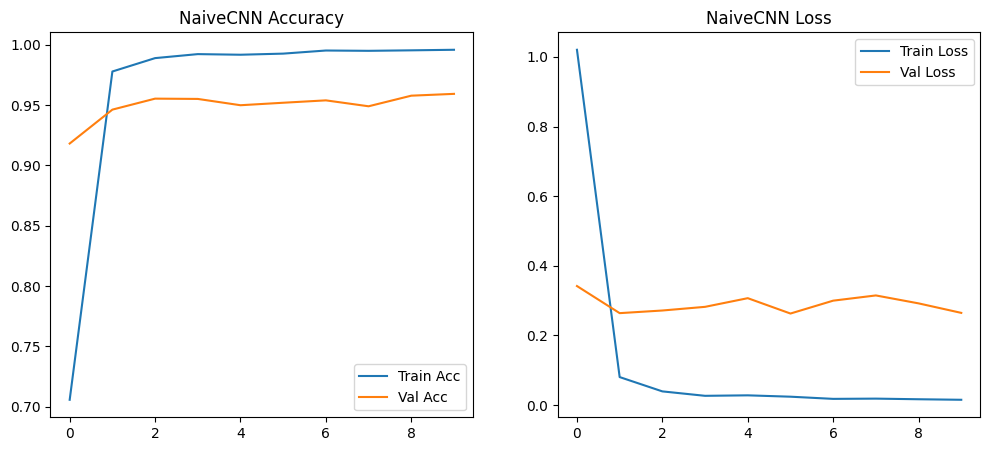

In [10]:
seed_everything(42)
transform = transforms.Compose([transforms.Resize((30, 30)), transforms.ToTensor()])
train_loader = DataLoader(GTSRBDataset(train_path, transform), batch_size=64, shuffle=True)
test_loader = DataLoader(GTSRBDataset(test_path, transform, is_train=False), batch_size=64, shuffle=False)

model = NaiveCNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optimizer, 10, "NaiveCNN")
evaluate_model(model, test_loader, "NaiveCNN")
print_parameters(model, "NaiveCNN")
plot_history(history, "NaiveCNN")

### Section 2: GAPOnlyCNN (48x48)

Epoch 1 | Loss: 2.7082 | Acc: 21.19% | Val Acc: 37.47%
Epoch 2 | Loss: 1.3640 | Acc: 54.59% | Val Acc: 67.79%
Epoch 3 | Loss: 0.4990 | Acc: 84.10% | Val Acc: 84.72%
Epoch 4 | Loss: 0.1916 | Acc: 94.29% | Val Acc: 87.95%
Epoch 5 | Loss: 0.1142 | Acc: 96.70% | Val Acc: 90.26%
Epoch 6 | Loss: 0.0784 | Acc: 97.71% | Val Acc: 92.17%
Epoch 7 | Loss: 0.0567 | Acc: 98.33% | Val Acc: 94.12%
Epoch 8 | Loss: 0.0442 | Acc: 98.70% | Val Acc: 93.37%
Epoch 9 | Loss: 0.0399 | Acc: 98.78% | Val Acc: 92.89%
Epoch 10 | Loss: 0.0324 | Acc: 98.95% | Val Acc: 93.85%
--- Evaluating GAPOnlyCNN ---
Total Images: 12630
Correct: 11853
Accuracy: 93.85%


==================== [GAPOnlyCNN Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
features.0.weight                        | [32, 3, 5, 5]             |           2,400
features.0.bias                     

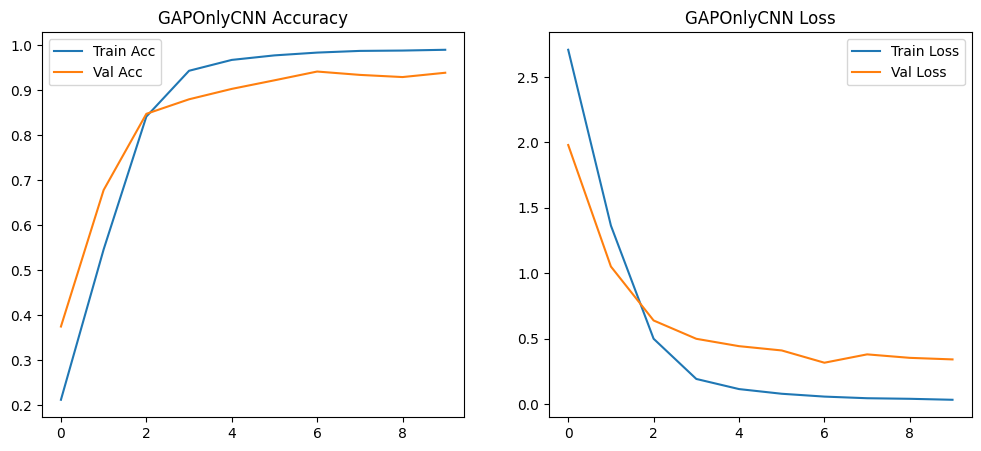

In [11]:
seed_everything(42)
transform = transforms.Compose([transforms.Resize((48, 48)), transforms.ToTensor()])
train_loader = DataLoader(GTSRBDataset(train_path, transform), batch_size=64, shuffle=True)
test_loader = DataLoader(GTSRBDataset(test_path, transform, is_train=False), batch_size=64, shuffle=False)

model = GAPOnlyCNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optimizer, 10, "GAPOnlyCNN")
evaluate_model(model, test_loader, "GAPOnlyCNN")
print_parameters(model, "GAPOnlyCNN")
plot_history(history, "GAPOnlyCNN")

### Section 3: DSConvCNN (48x48)

Epoch 1 | Loss: 2.1629 | Acc: 34.35% | Val Acc: 48.57%
Epoch 2 | Loss: 0.9133 | Acc: 70.47% | Val Acc: 74.87%
Epoch 3 | Loss: 0.4241 | Acc: 86.71% | Val Acc: 83.22%
Epoch 4 | Loss: 0.2540 | Acc: 92.03% | Val Acc: 77.43%
Epoch 5 | Loss: 0.1636 | Acc: 94.84% | Val Acc: 85.49%
Epoch 6 | Loss: 0.1310 | Acc: 95.90% | Val Acc: 88.42%
Epoch 7 | Loss: 0.1046 | Acc: 96.77% | Val Acc: 88.77%
Epoch 8 | Loss: 0.0850 | Acc: 97.26% | Val Acc: 90.01%
Epoch 9 | Loss: 0.0712 | Acc: 97.76% | Val Acc: 88.90%
Epoch 10 | Loss: 0.0679 | Acc: 97.75% | Val Acc: 89.96%
--- Evaluating DSConvCNN ---
Total Images: 12630
Correct: 11362
Accuracy: 89.96%


==================== [DSConvCNN Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
conv1.depthwise.weight                   | [3, 1, 5, 5]              |              75
conv1.bn1.weight                      

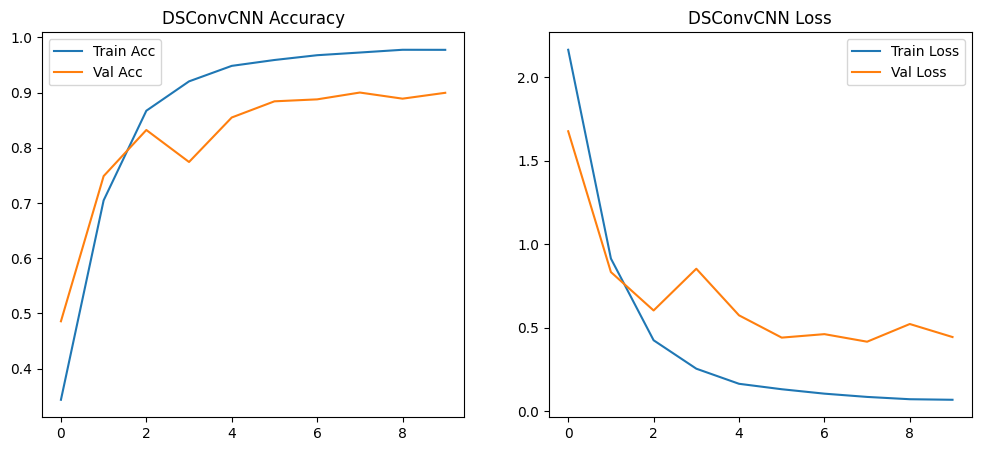

In [12]:
seed_everything(42)
transform = transforms.Compose([transforms.Resize((48, 48)), transforms.ToTensor()])
train_loader = DataLoader(GTSRBDataset(train_path, transform), batch_size=64, shuffle=True)
test_loader = DataLoader(GTSRBDataset(test_path, transform, is_train=False), batch_size=64, shuffle=False)

model = DSConvCNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optimizer, 10, "DSConvCNN")
evaluate_model(model, test_loader, "DSConvCNN")
print_parameters(model, "DSConvCNN")
plot_history(history, "DSConvCNN")

### Section 4: DSResidualNet (48x48)

Epoch 1 | Loss: 1.5867 | Acc: 52.78% | Val Acc: 83.13%
Epoch 2 | Loss: 0.1583 | Acc: 95.64% | Val Acc: 93.75%
Epoch 3 | Loss: 0.0512 | Acc: 98.59% | Val Acc: 95.27%
Epoch 4 | Loss: 0.0330 | Acc: 99.06% | Val Acc: 95.98%
Epoch 5 | Loss: 0.0270 | Acc: 99.23% | Val Acc: 93.91%
Epoch 6 | Loss: 0.0224 | Acc: 99.35% | Val Acc: 95.71%
Epoch 7 | Loss: 0.0238 | Acc: 99.32% | Val Acc: 95.80%
Epoch 8 | Loss: 0.0184 | Acc: 99.41% | Val Acc: 96.27%
Epoch 9 | Loss: 0.0194 | Acc: 99.40% | Val Acc: 96.68%
Epoch 10 | Loss: 0.0198 | Acc: 99.39% | Val Acc: 96.04%
--- Evaluating DSResidualNet ---
Total Images: 12630
Correct: 12130
Accuracy: 96.04%


==================== [DSResidualNet Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
conv1.depthwise.weight                   | [3, 1, 5, 5]              |              75
conv1.bn1.weight              

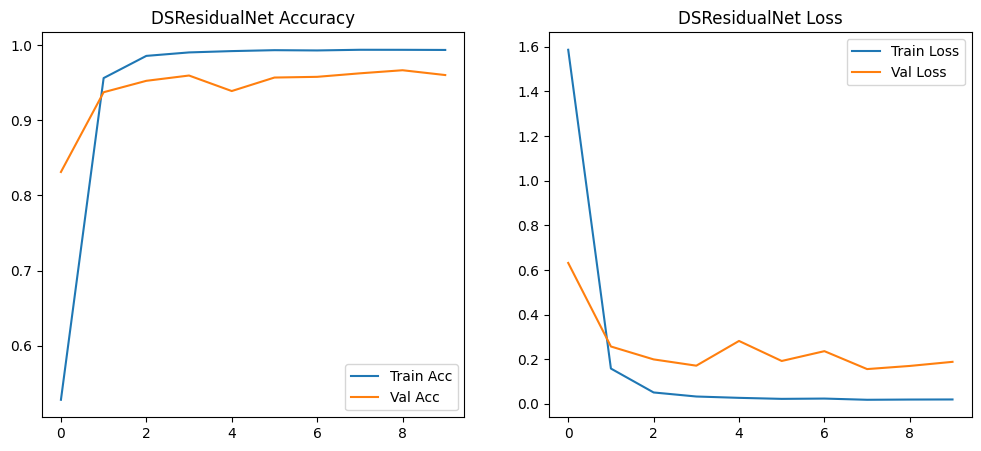

In [13]:
seed_everything(42)
transform = transforms.Compose([transforms.Resize((48, 48)), transforms.ToTensor()])
train_loader = DataLoader(GTSRBDataset(train_path, transform), batch_size=64, shuffle=True)
test_loader = DataLoader(GTSRBDataset(test_path, transform, is_train=False), batch_size=64, shuffle=False)

model = DSResidualNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optimizer, 10, "DSResidualNet")
evaluate_model(model, test_loader, "DSResidualNet")
print_parameters(model, "DSResidualNet")
plot_history(history, "DSResidualNet")

### Section 5: DSResidualSENet (48x48)

Epoch 1 | Loss: 1.4714 | Acc: 57.34% | Val Acc: 76.61%
Epoch 2 | Loss: 0.2675 | Acc: 92.00% | Val Acc: 84.35%
Epoch 3 | Loss: 0.1204 | Acc: 96.35% | Val Acc: 87.77%
Epoch 4 | Loss: 0.0799 | Acc: 97.52% | Val Acc: 89.49%
Epoch 5 | Loss: 0.0607 | Acc: 98.12% | Val Acc: 89.56%
Epoch 6 | Loss: 0.0582 | Acc: 98.24% | Val Acc: 89.52%
Epoch 7 | Loss: 0.0464 | Acc: 98.55% | Val Acc: 90.47%
Epoch 8 | Loss: 0.0421 | Acc: 98.67% | Val Acc: 90.09%
Epoch 9 | Loss: 0.0383 | Acc: 98.73% | Val Acc: 91.43%
Epoch 10 | Loss: 0.0355 | Acc: 98.85% | Val Acc: 90.81%
--- Evaluating DSResidualSENet ---
Total Images: 12630
Correct: 11469
Accuracy: 90.81%


==================== [DSResidualSENet Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
features.0.depthwise.weight              | [3, 1, 3, 3]              |              27
features.0.bn1.weight     

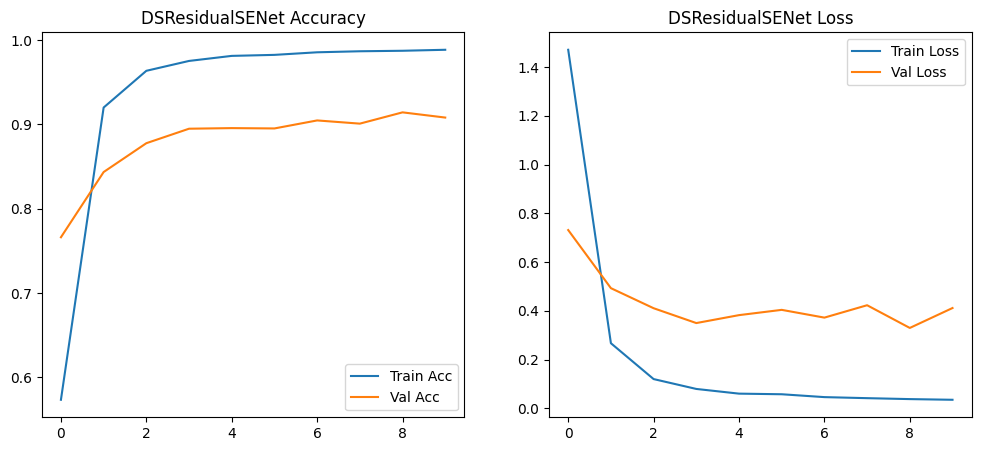

In [14]:
seed_everything(42)
transform = transforms.Compose([transforms.Resize((48, 48)), transforms.ToTensor()])
train_loader = DataLoader(GTSRBDataset(train_path, transform), batch_size=64, shuffle=True)
test_loader = DataLoader(GTSRBDataset(test_path, transform, is_train=False), batch_size=64, shuffle=False)

model = DSResidualSENet()
optimizer = optim.Adam(model.parameters(), lr=0.001)
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optimizer, 10, "DSResidualSENet")
evaluate_model(model, test_loader, "DSResidualSENet")
print_parameters(model, "DSResidualSENet")
plot_history(history, "DSResidualSENet")

### Section 6: DSResidualSAMNet (48x48)

Epoch 1 | Loss: 1.7811 | Acc: 46.84% | Val Acc: 78.23%
Epoch 2 | Loss: 0.1985 | Acc: 95.11% | Val Acc: 93.02%
Epoch 3 | Loss: 0.0459 | Acc: 99.01% | Val Acc: 96.22%
Epoch 4 | Loss: 0.0244 | Acc: 99.54% | Val Acc: 96.22%
Epoch 5 | Loss: 0.0147 | Acc: 99.72% | Val Acc: 96.24%
Epoch 6 | Loss: 0.0111 | Acc: 99.79% | Val Acc: 97.21%
Epoch 7 | Loss: 0.0089 | Acc: 99.85% | Val Acc: 96.41%
Epoch 8 | Loss: 0.0070 | Acc: 99.87% | Val Acc: 97.02%
Epoch 9 | Loss: 0.0059 | Acc: 99.89% | Val Acc: 97.15%
Epoch 10 | Loss: 0.0053 | Acc: 99.89% | Val Acc: 97.45%
--- Evaluating DSResidualSAMNet ---
Total Images: 12630
Correct: 12308
Accuracy: 97.45%


==================== [DSResidualSAMNet Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
conv1.depthwise.weight                   | [3, 1, 5, 5]              |              75
conv1.bn1.weight        

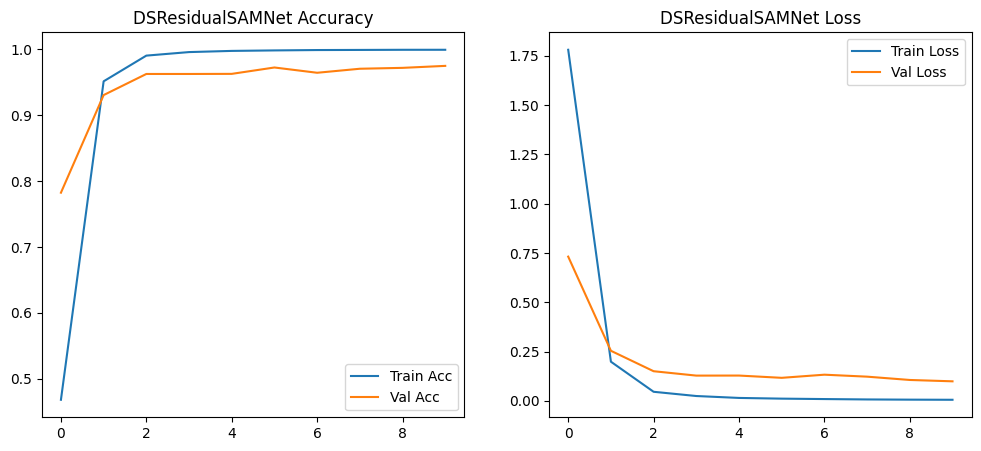

In [15]:
seed_everything(42)
transform = transforms.Compose([transforms.Resize((48, 48)), transforms.ToTensor()])
train_loader = DataLoader(GTSRBDataset(train_path, transform), batch_size=64, shuffle=True)
test_loader = DataLoader(GTSRBDataset(test_path, transform, is_train=False), batch_size=64, shuffle=False)

model = DSResidualNet()
base_optimizer = optim.Adam
optimizer = SAM(model.parameters(), base_optimizer, lr=0.001)
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optimizer, 10, "DSResidualSAMNet", use_sam=True)
evaluate_model(model, test_loader, "DSResidualSAMNet")
print_parameters(model, "DSResidualSAMNet")
plot_history(history, "DSResidualSAMNet")

### Section 7: DSResidualSAMSENet

Epoch 1 | Loss: 1.5512 | Acc: 55.05% | Val Acc: 78.35%
Epoch 2 | Loss: 0.2609 | Acc: 92.62% | Val Acc: 88.38%
Epoch 3 | Loss: 0.0979 | Acc: 97.50% | Val Acc: 88.50%
Epoch 4 | Loss: 0.0615 | Acc: 98.43% | Val Acc: 91.67%
Epoch 5 | Loss: 0.0414 | Acc: 98.90% | Val Acc: 90.87%
Epoch 6 | Loss: 0.0337 | Acc: 99.25% | Val Acc: 92.90%
Epoch 7 | Loss: 0.0284 | Acc: 99.24% | Val Acc: 92.00%
Epoch 8 | Loss: 0.0231 | Acc: 99.40% | Val Acc: 92.09%
Epoch 9 | Loss: 0.0201 | Acc: 99.50% | Val Acc: 93.59%
Epoch 10 | Loss: 0.0169 | Acc: 99.60% | Val Acc: 93.37%
--- Evaluating DSResidualSAMSENet ---
Total Images: 12630
Correct: 11792
Accuracy: 93.37%


==================== [DSResidualSAMSENet Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
features.0.depthwise.weight              | [3, 1, 3, 3]              |              27
features.0.bn1.weigh

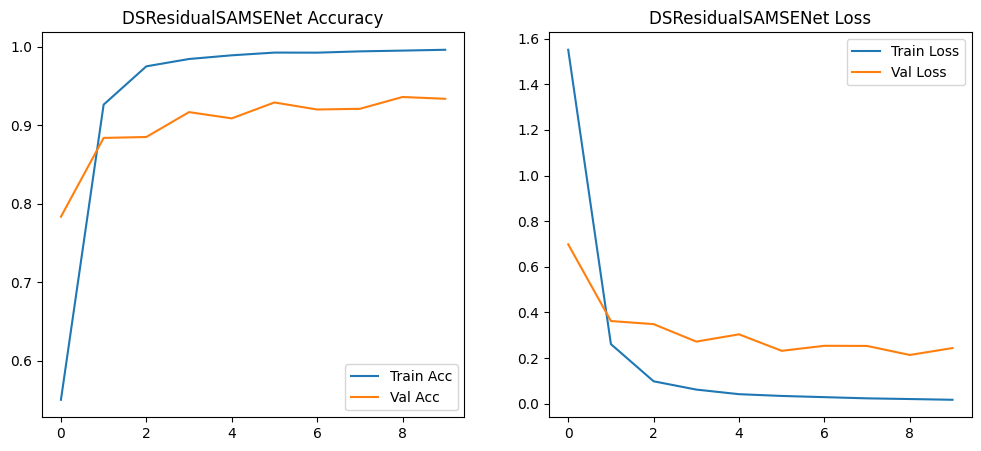

In [16]:
seed_everything(42)
transform = transforms.Compose([transforms.Resize((48, 48)), transforms.ToTensor()])
train_loader = DataLoader(GTSRBDataset(train_path, transform), batch_size=64, shuffle=True)
test_loader = DataLoader(GTSRBDataset(test_path, transform, is_train=False), batch_size=64, shuffle=False)

model = DSResidualSENet()
base_optimizer = optim.Adam
optimizer = SAM(model.parameters(), base_optimizer, lr=0.001)
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optimizer, 10, "DSResidualSAMSENet", use_sam=True)
evaluate_model(model, test_loader, "DSResidualSAMSENet")
print_parameters(model, "DSResidualSAMSENet")
plot_history(history, "DSResidualSAMSENet")

### Section 8: DSResidualSAMNet (Weighted Sampler)

Epoch 1 | Loss: 2.3756 | Acc: 28.38% | Val Acc: 43.73%
Epoch 2 | Loss: 0.5317 | Acc: 83.94% | Val Acc: 90.60%
Epoch 3 | Loss: 0.1215 | Acc: 97.00% | Val Acc: 95.11%
Epoch 4 | Loss: 0.0579 | Acc: 98.61% | Val Acc: 96.81%
Epoch 5 | Loss: 0.0422 | Acc: 98.98% | Val Acc: 97.74%
Epoch 6 | Loss: 0.0302 | Acc: 99.31% | Val Acc: 96.98%
Epoch 7 | Loss: 0.0246 | Acc: 99.41% | Val Acc: 97.18%
Epoch 8 | Loss: 0.0210 | Acc: 99.51% | Val Acc: 97.85%
Epoch 9 | Loss: 0.0188 | Acc: 99.57% | Val Acc: 98.15%
Epoch 10 | Loss: 0.0160 | Acc: 99.63% | Val Acc: 98.32%
--- Evaluating DSResidualSAMNet_W ---
Total Images: 12630
Correct: 12418
Accuracy: 98.32%


==================== [DSResidualSAMNet_W Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
conv1.depthwise.weight                   | [3, 1, 5, 5]              |              75
conv1.bn1.weight    

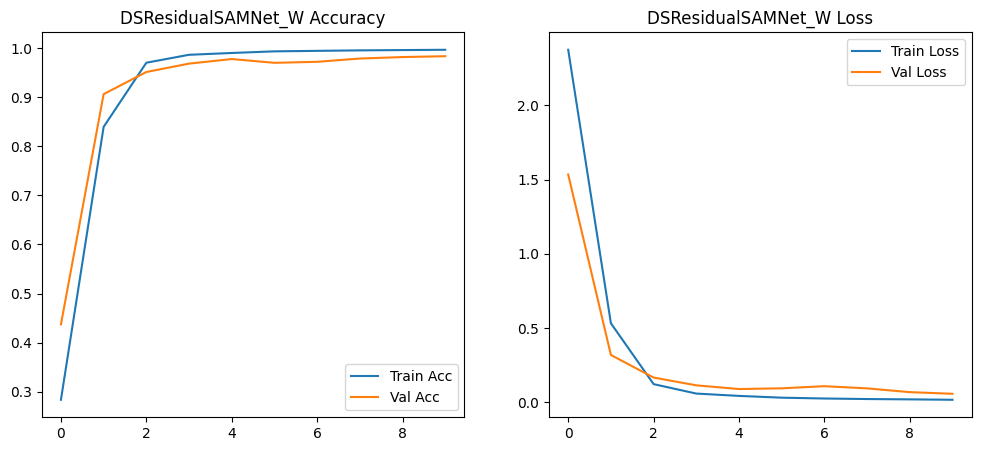

In [17]:
seed_everything(42)
def create_sampler(dataset):
    targets = [label for _, label in dataset.samples]
    class_counts = np.bincount(targets)
    class_weights = 1.0 / class_counts
    sample_weights = [class_weights[label] for label in targets]
    sample_weights = torch.DoubleTensor(sample_weights)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

transform_train_48 = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])
transform_test_48 = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])
train_dataset = GTSRBDataset(train_path, transform_train_48)
train_loader = DataLoader(train_dataset, batch_size=64, sampler=create_sampler(train_dataset))
test_loader = DataLoader(GTSRBDataset(test_path, transform_test_48, is_train=False), batch_size=64, shuffle=False)

model = DSResidualNet()
base_optimizer = optim.Adam
optimizer = SAM(model.parameters(), base_optimizer, lr=0.001)
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optimizer, 10, "DSResidualSAMNet_W", use_sam=True)
evaluate_model(model, test_loader, "DSResidualSAMNet_W")
print_parameters(model, "DSResidualSAMNet_W")
plot_history(history, "DSResidualSAMNet_W")

### Section 9: DSResidualSAMSENet (Weighted Sampler)

Epoch 1 | Loss: 2.1189 | Acc: 37.73% | Val Acc: 58.47%
Epoch 2 | Loss: 0.6064 | Acc: 80.42% | Val Acc: 78.84%
Epoch 3 | Loss: 0.2910 | Acc: 90.81% | Val Acc: 86.72%
Epoch 4 | Loss: 0.1807 | Acc: 94.44% | Val Acc: 90.24%
Epoch 5 | Loss: 0.1317 | Acc: 96.02% | Val Acc: 92.32%
Epoch 6 | Loss: 0.1045 | Acc: 96.82% | Val Acc: 93.95%
Epoch 7 | Loss: 0.0876 | Acc: 97.32% | Val Acc: 93.78%
Epoch 8 | Loss: 0.0732 | Acc: 97.84% | Val Acc: 94.81%
Epoch 9 | Loss: 0.0630 | Acc: 98.09% | Val Acc: 95.45%
Epoch 10 | Loss: 0.0532 | Acc: 98.47% | Val Acc: 96.10%
--- Evaluating DSResidualSENet_W ---
Total Images: 12630
Correct: 12137
Accuracy: 96.10%


==================== [DSResidualSENet_W Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
features.0.depthwise.weight              | [3, 1, 3, 3]              |              27
features.0.bn1.weight 

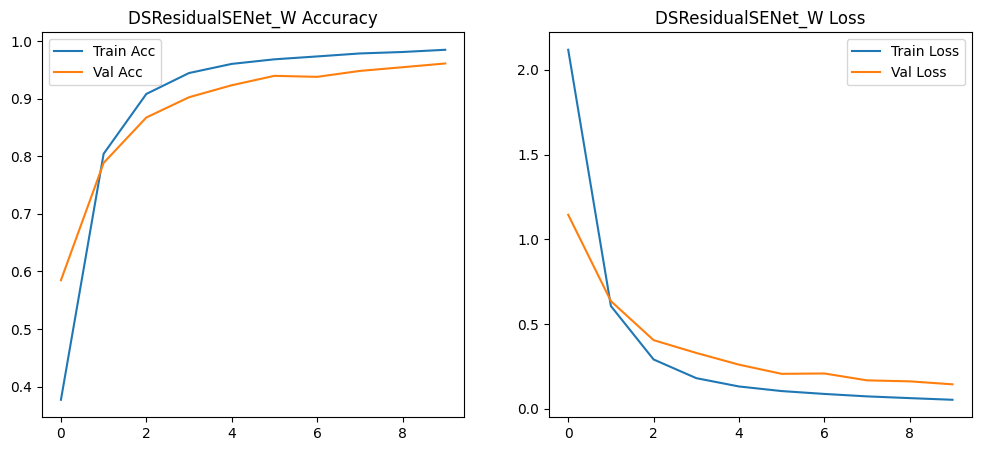

In [18]:
seed_everything(42)
transform_train_48 = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])
transform_test_48 = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])
train_dataset = GTSRBDataset(train_path, transform_train_48)
train_loader = DataLoader(train_dataset, batch_size=64, sampler=create_sampler(train_dataset))
test_loader = DataLoader(GTSRBDataset(test_path, transform_test_48, is_train=False), batch_size=64, shuffle=False)

model = DSResidualSENet()
base_optimizer = optim.Adam
optimizer = SAM(model.parameters(), base_optimizer, lr=0.001)
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optimizer, 10, "DSResidualSENet_W", use_sam=True)
evaluate_model(model, test_loader, "DSResidualSENet_W")
print_parameters(model, "DSResidualSENet_W")
plot_history(history, "DSResidualSENet_W")

### Section 10: DSResidualSAMNetDilation (48x48)

Epoch 1 | Loss: 2.0195 | Acc: 39.92% | Val Acc: 62.66%
Epoch 2 | Loss: 0.3909 | Acc: 88.59% | Val Acc: 90.16%
Epoch 3 | Loss: 0.0879 | Acc: 98.03% | Val Acc: 93.15%
Epoch 4 | Loss: 0.0364 | Acc: 99.30% | Val Acc: 94.70%
Epoch 5 | Loss: 0.0228 | Acc: 99.54% | Val Acc: 95.38%
Epoch 6 | Loss: 0.0163 | Acc: 99.70% | Val Acc: 95.65%
Epoch 7 | Loss: 0.0131 | Acc: 99.71% | Val Acc: 96.14%
Epoch 8 | Loss: 0.0095 | Acc: 99.82% | Val Acc: 96.44%
Epoch 9 | Loss: 0.0070 | Acc: 99.87% | Val Acc: 96.25%
Epoch 10 | Loss: 0.0065 | Acc: 99.87% | Val Acc: 95.68%
--- Evaluating DSResidualSAMNetDilation ---
Total Images: 12630
Correct: 12084
Accuracy: 95.68%


==================== [DSResidualSAMNetDilation Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
conv1.depthwise.weight                   | [3, 1, 5, 5]              |              75
conv1.bn

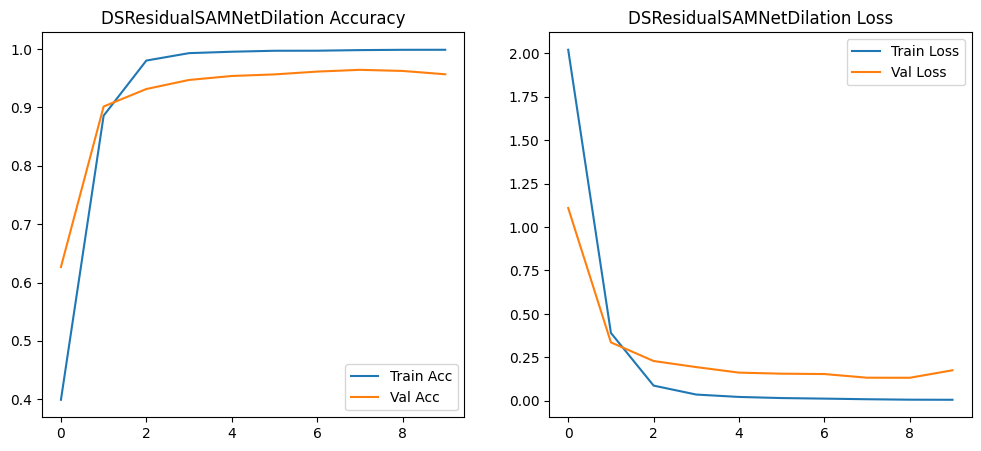

In [19]:
seed_everything(42)
transform = transforms.Compose([transforms.Resize((48, 48)), transforms.ToTensor()])
train_loader = DataLoader(GTSRBDataset(train_path, transform), batch_size=64, shuffle=True)
test_loader = DataLoader(GTSRBDataset(test_path, transform, is_train=False), batch_size=64, shuffle=False)

model = DSResidualNetDilation()
base_optimizer = optim.Adam
optimizer = SAM(model.parameters(), base_optimizer, lr=0.001)
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optimizer, 10, "DSResidualSAMNetDilation", use_sam=True)
evaluate_model(model, test_loader, "DSResidualSAMNetDilation")
print_parameters(model, "DSResidualSAMNetDilation")
plot_history(history, "DSResidualSAMNetDilation")

## 5. 실험 결과 확인 및 시각화

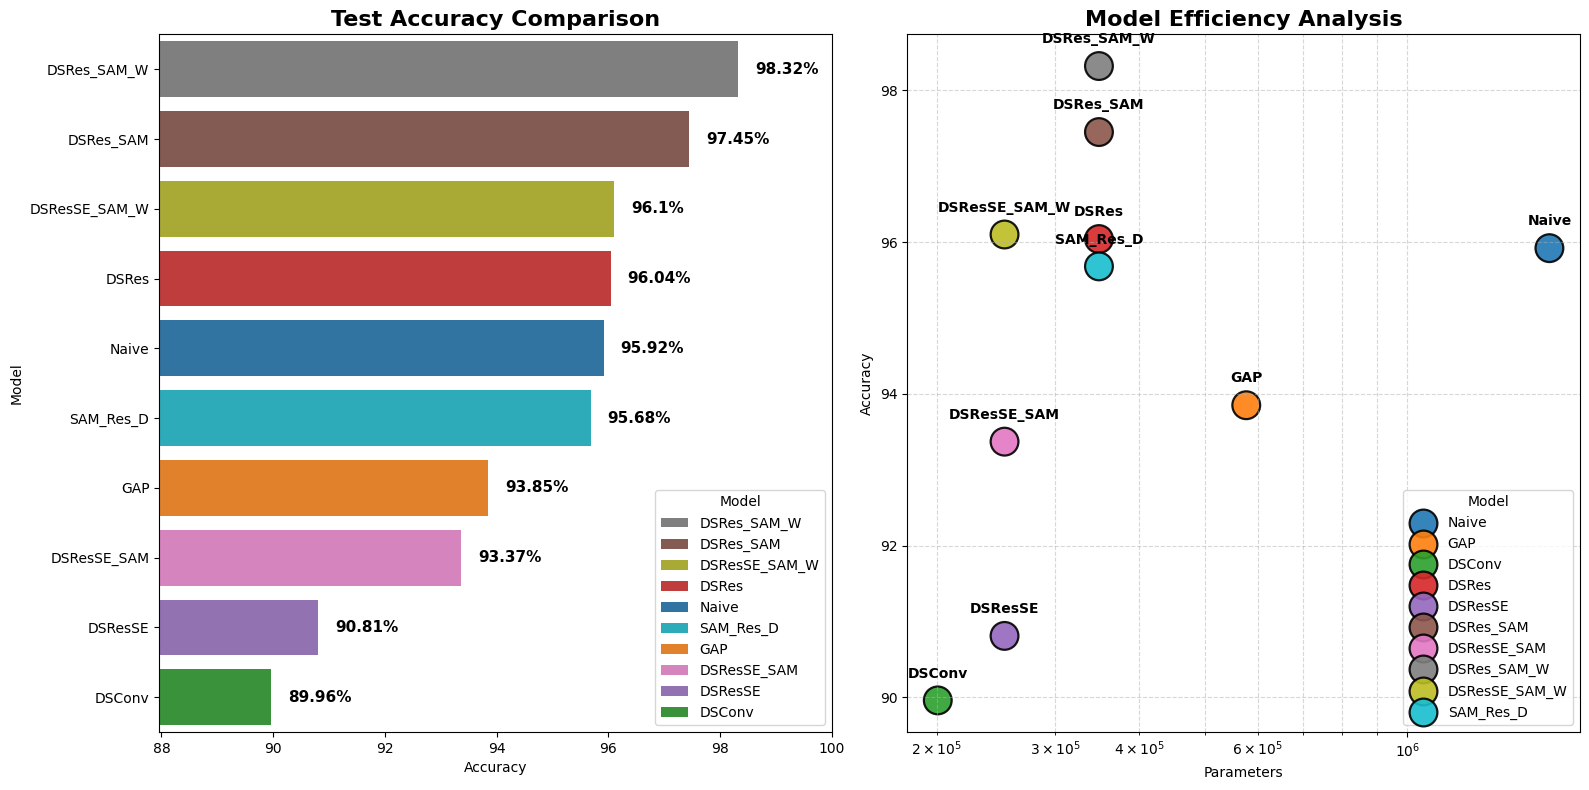


--- [GTSRB Experiment Summary Table] ---
        Model  Accuracy  Parameters
  DSRes_SAM_W     98.32      348348
    DSRes_SAM     97.45      348348
DSResSE_SAM_W     96.10      252250
        DSRes     96.04      348348
        Naive     95.92     1624939
    SAM_Res_D     95.68      348348
          GAP     93.85      576363
  DSResSE_SAM     93.37      252250
      DSResSE     90.81      252250
       DSConv     89.96      200764


In [24]:
results_data = {
    "Model": ["Naive", "GAP", "DSConv", "DSRes", "DSResSE", "DSRes_SAM", "DSResSE_SAM", "DSRes_SAM_W", "DSResSE_SAM_W", "SAM_Res_D"],
    "Accuracy": [95.92, 93.85, 89.96, 96.04, 90.81, 97.45, 93.37, 98.32, 96.10, 95.68],
    "Parameters": [1624939, 576363, 200764, 348348, 252250, 348348, 252250, 348348, 252250, 348348]
}
df_res = pd.DataFrame(results_data)

unique_models = df_res["Model"].unique()
color_palette = dict(zip(unique_models, sns.color_palette("tab10", len(unique_models))))
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sorted_df = df_res.sort_values("Accuracy", ascending=False)
sns.barplot(x="Accuracy", y="Model", data=sorted_df, hue="Model", palette=color_palette, legend=True)
plt.title("Test Accuracy Comparison", fontsize=16, fontweight='bold')
plt.xlim(min(df_res["Accuracy"]) - 2, 100) 
for i, v in enumerate(sorted_df["Accuracy"]):
    plt.text(v + 0.3, i, f"{v}%", va='center', fontweight='bold', fontsize=11)

plt.subplot(1, 2, 2)
sns.scatterplot(x="Parameters", y="Accuracy", hue="Model", palette=color_palette, 
                s=400, data=df_res, edgecolor='black', alpha=0.9, legend=True)
plt.title("Model Efficiency Analysis", fontsize=16, fontweight='bold')
plt.xscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)

for i in range(df_res.shape[0]):
    plt.text(df_res.Parameters[i], df_res.Accuracy[i] + 0.3, df_res.Model[i], 
             fontsize=10, fontweight='bold', ha='center', color='black')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("--- [GTSRB Experiment Summary Table] ---")
print("="*50)
print(sorted_df.to_string(index=False))


       [SAM_W 모델의 정답 샘플 시각화 분석 (5x5)]       


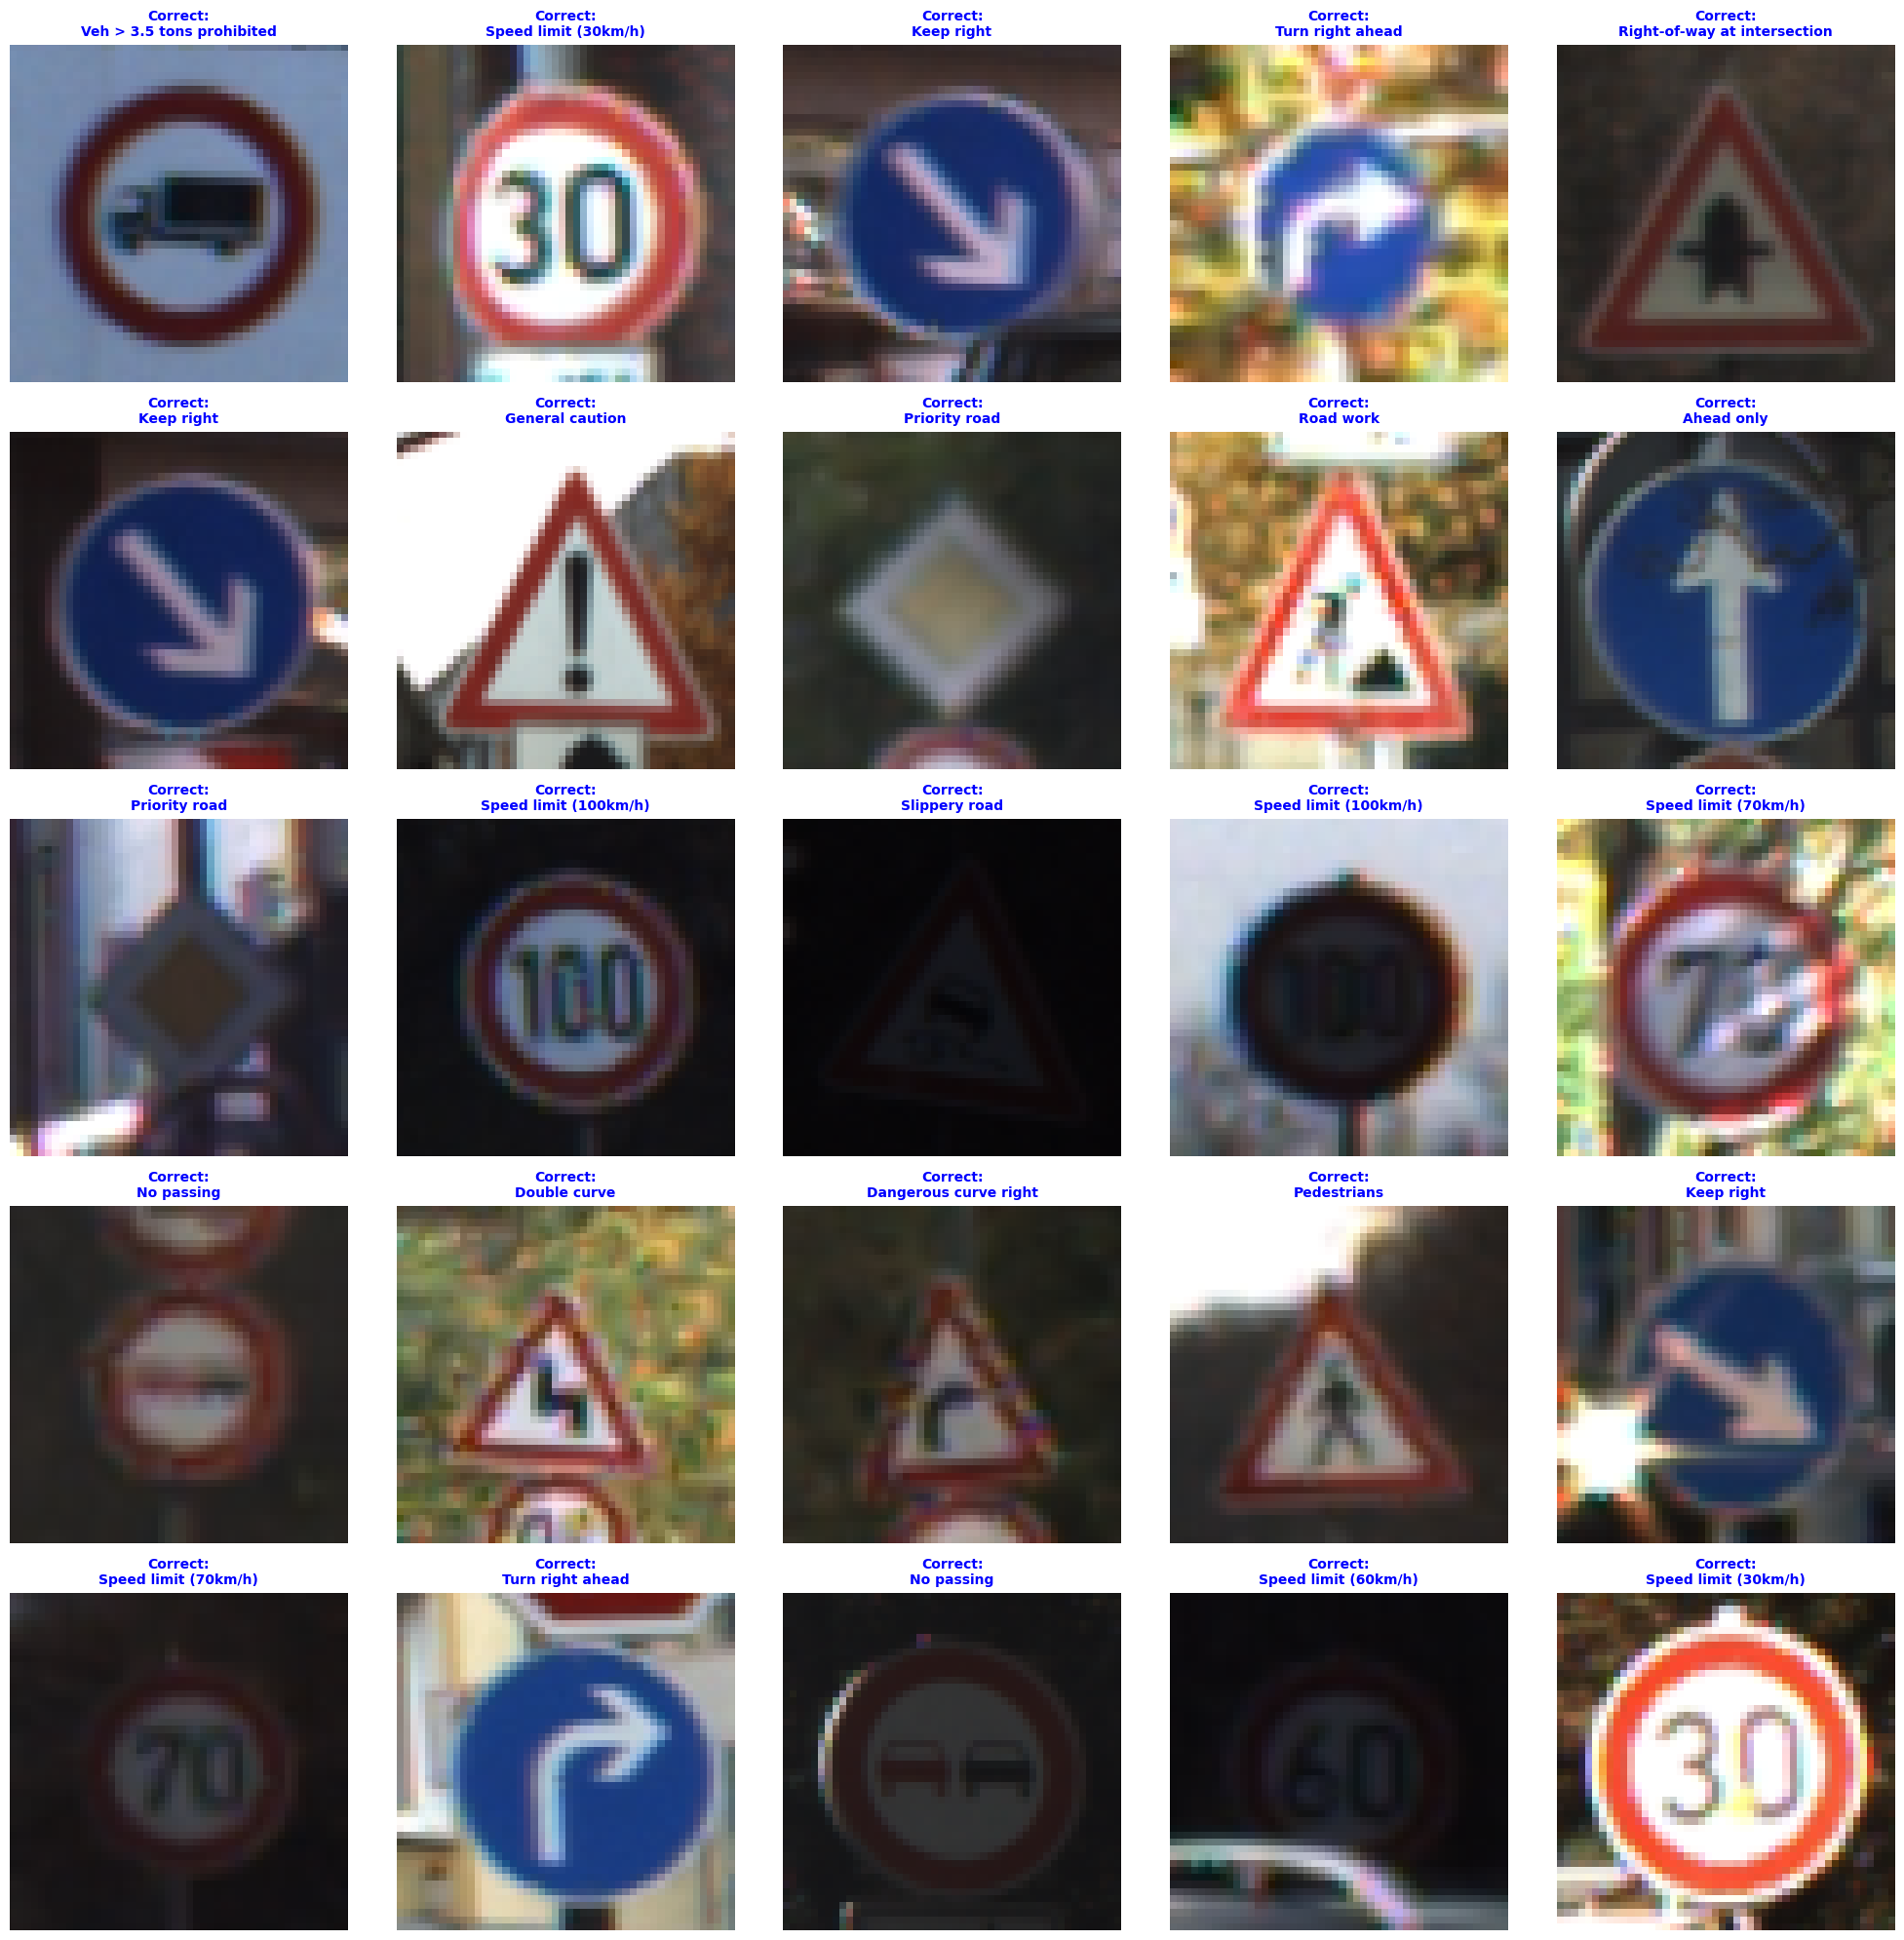

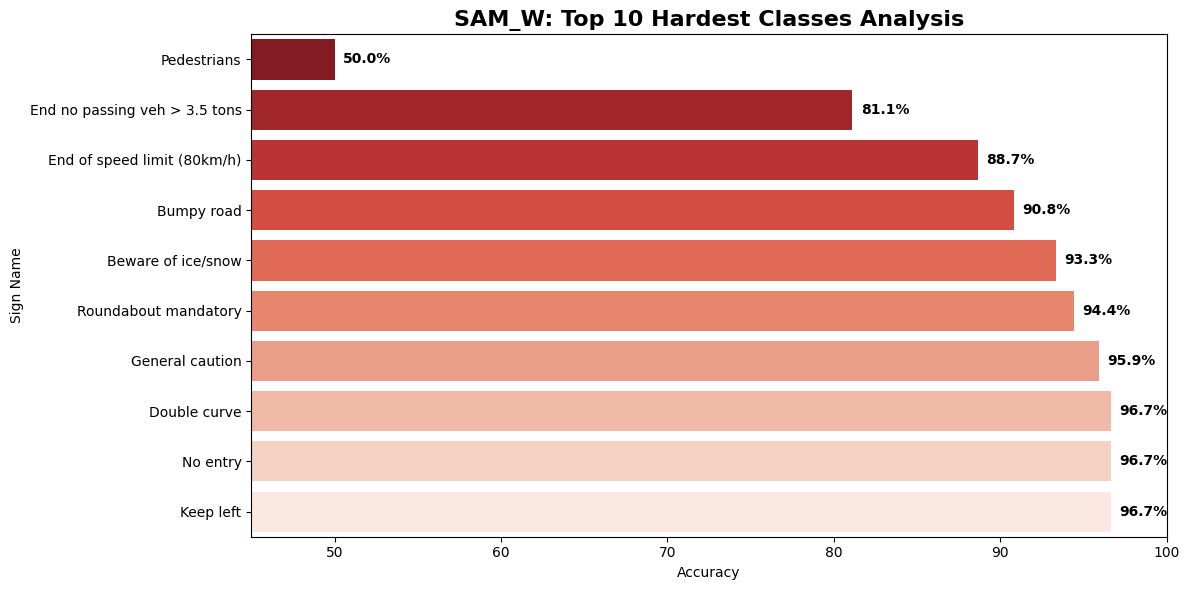


       [SAM_W 모델의 주요 오분류 샘플 시각화 분석 (2x5)]       


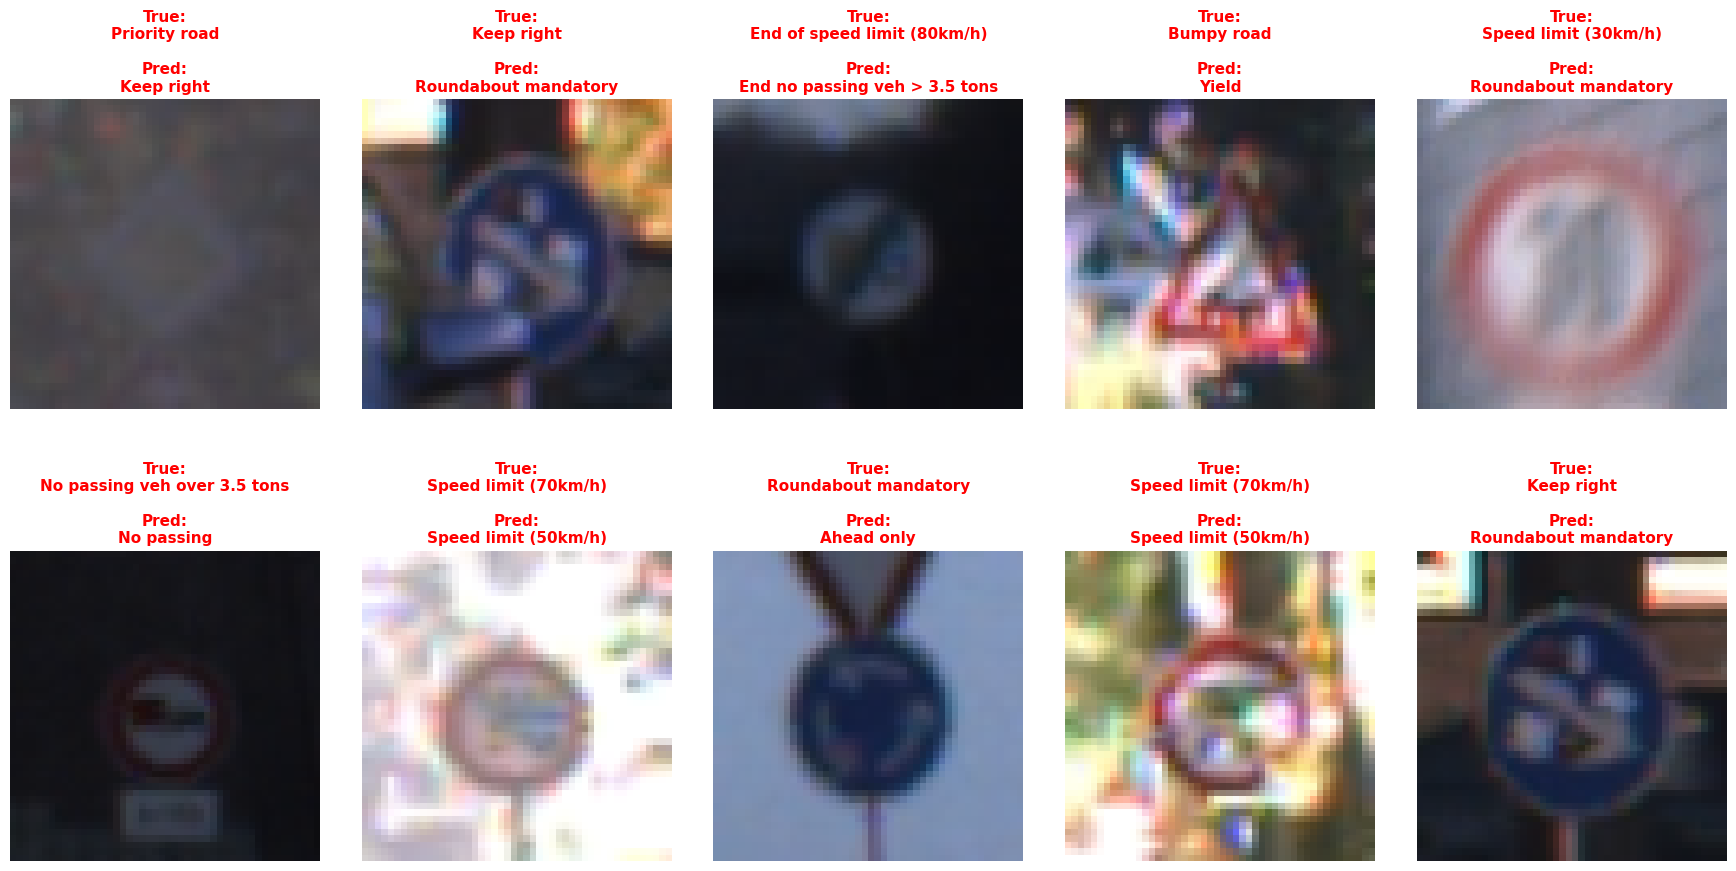

In [21]:

def get_detailed_analysis(model, loader, device='cuda'):
    model.eval()
    class_correct = list(0. for i in range(43))
    class_total = list(0. for i in range(43))
    
    misclassified_samples = []
    correct_samples = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            c = (predicted == labels).squeeze()
            
            for i in range(len(labels)):
                label = labels[i].item()
                class_correct[label] += c[i].item()
                class_total[label] += 1
                
                if predicted[i] != labels[i] and len(misclassified_samples) < 10:
                    misclassified_samples.append({
                        'image': images[i].cpu(),
                        'true_name': classes[label],
                        'pred_name': classes[predicted[i].item()]
                    })
                
                elif predicted[i] == labels[i] and len(correct_samples) < 25:
                    correct_samples.append({
                        'image': images[i].cpu(),
                        'name': classes[label]
                    })
    acc_data = []
    for i in range(43):
        accuracy = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
        acc_data.append({"Sign Name": classes[i], "Accuracy": accuracy})
    
    return pd.DataFrame(acc_data), misclassified_samples, correct_samples

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_sam_w = DSResidualNet().to(device)
model_sam_w.load_state_dict(torch.load('best_DSResidualSAMNet_W.pth', weights_only=True)) 
df_class_acc, mis_samples, cor_samples = get_detailed_analysis(model_sam_w, test_loader, device=device)

print("\n" + "="*70)
print("       [SAM_W 모델의 정답 샘플 시각화 분석 (5x5)]       ")
print("="*70)
plt.figure(figsize=(20, 20))
for i, sample in enumerate(cor_samples):
    plt.subplot(5, 5, i + 1)
    img = sample['image'].permute(1, 2, 0).numpy()
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"Correct:\n{sample['name']}", color='blue', fontsize=10, fontweight='bold')
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
top10_hardest = df_class_acc.sort_values("Accuracy").head(10)
sns.barplot(x="Accuracy", y="Sign Name", data=top10_hardest, hue="Sign Name", palette="Reds_r", legend=False)
plt.title("SAM_W: Top 10 Hardest Classes Analysis", fontsize=16, fontweight='bold')
plt.xlim(max(0, min(top10_hardest["Accuracy"]) - 5), 100)
for i, v in enumerate(top10_hardest["Accuracy"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("       [SAM_W 모델의 주요 오분류 샘플 시각화 분석 (2x5)]       ")
print("="*70)
plt.figure(figsize=(18, 10)) 
for i, sample in enumerate(mis_samples):
    plt.subplot(2, 5, i + 1)
    img = sample['image'].permute(1, 2, 0).numpy()
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"True:\n{sample['true_name']}\n\nPred:\n{sample['pred_name']}", color='red', fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout(pad=3.0) 
plt.show()